<a href="https://colab.research.google.com/github/Himanshu0518/fnp-Sales-Data-Analysis/blob/main/notebooks/fanp_cohort_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# imports
import numpy as np
import pandas as pd

In [30]:
order_df = pd.read_csv("/content/orders.csv")
order_df.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali
2,3,C029,67,5,14-07-2023,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary
3,4,C012,14,5,10-07-2023,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday
4,5,C078,58,2,11-02-2023,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day


In [31]:
customer_df=pd.read_csv('/content/customers.csv')
customer_df.head()

,Customer_ID,Name,City,Contact_Number,Email,Gender,Address
0,C001,Tara Krishnan,Panchkula,917193971454,mandrati@chad.org,Female,"65/04\nDhawan Marg, Rajpur Sonarpur 590551"
1,C002,Myra Edwin,Bulandshahr,8915420519,yshukla@hotmail.com,Female,H.No. 78\nSharaf Ganj\nIndore 928261
2,C003,Jayesh Lanka,Bilaspur,7400208126,kavyabarad@hotmail.com,Male,"H.No. 53, Krishna Ganj, Dhule-346480"
3,C004,Tarini Bava,Miryalaguda,7232349928,vsen@hotmail.com,Male,"145\nSibal, Rourkela-650344"
4,C005,Hiran Kaul,Kottayam,2207644242,hanshkapur@buch.biz,Male,34/168\nSachar Street\nBhatpara 002691


In [32]:
products_df=pd.read_csv('/content/products.csv')
products_df.head()

,Product_ID,Product_Name,Category,Price (INR),Occasion,Description
0,1,Magnam Set,Soft Toys,1935,All Occasions,Quam numquam iste sunt nemo.
1,2,Voluptas Box,Plants,441,Valentine's Day,At quaerat animi nemo.
2,3,Eius Gift,Colors,1534,Valentine's Day,Deserunt pariatur mollitia voluptatem.
3,4,Accusantium Set,Sweets,1199,Diwali,Corporis odio consequatur perferendis repellen...
4,5,Natus Gift,Colors,1444,All Occasions,Quis occaecati reprehenderit facere tenetur il...


In [33]:
df = pd.merge(order_df, products_df, on='Product_ID', suffixes=('_order', '_product'))

df = df.drop(columns=['Occasion_product'])
df = df.rename(columns={'Occasion_order': 'Occasion'})

df['Revenue'] = df['Quantity'] * df['Price (INR)']

df.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion,Product_Name,Category,Price (INR),Description,Revenue
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali,Aut Box,Sweets,1977,Ab quisquam nobis ducimus.,3954
2,3,C029,67,5,14-07-2023,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870
3,4,C012,14,5,10-07-2023,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday,Deserunt Box,Colors,1915,Incidunt hic vero esse saepe illum.,9575
4,5,C078,58,2,11-02-2023,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day,Sed Pack,Cake,1492,Reiciendis nam omnis vel explicabo amet perfer...,2984


### Cohort Analysis: Defining Cohorts

To perform cohort analysis, we'll first convert the `Order_Date` column to datetime objects and then determine the first purchase date for each customer. This 'first purchase date' will define the cohort each customer belongs to.

In [34]:
# Convert Order_Date to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

In [35]:
# Get the first order date for each customer
first_order_date = df.groupby('Customer_ID')['Order_Date'].min().reset_index()
first_order_date.columns = ['Customer_ID', 'First_Order_Date']
first_order_date.head()

,Customer_ID,First_Order_Date
0,C001,2023-02-12
1,C002,2023-03-03
2,C003,2023-02-07
3,C004,2023-02-13
4,C005,2023-03-05


In [36]:

if 'First_Order_Date' in df.columns:
    df = df.drop(columns=['First_Order_Date'])
df = pd.merge(df, first_order_date, on='Customer_ID', how='left')

# Define Cohort (month of first purchase)
df['Cohort'] = df['First_Order_Date'].dt.to_period('M')

# Calculate Cohort Period (number of months since first purchase)
df['Cohort_Period'] = (df['Order_Date'].dt.to_period('M') - df['Cohort']).apply(lambda x: x.n)

df.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion,Product_Name,Category,Price (INR),Description,Revenue,First_Order_Date,Cohort,Cohort_Period
0,1,C037,67,5,2023-02-24,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870,2023-02-02,2023-02,0
1,2,C019,41,2,2023-11-07,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali,Aut Box,Sweets,1977,Ab quisquam nobis ducimus.,3954,2023-02-04,2023-02,9
2,3,C029,67,5,2023-07-14,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870,2023-02-28,2023-02,5
3,4,C012,14,5,2023-07-10,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday,Deserunt Box,Colors,1915,Incidunt hic vero esse saepe illum.,9575,2023-01-08,2023-01,6
4,5,C078,58,2,2023-02-11,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day,Sed Pack,Cake,1492,Reiciendis nam omnis vel explicabo amet perfer...,2984,2023-02-04,2023-02,0


### Cohort Analysis: Aggregating Customer Counts

Before calculating retention, we need to aggregate the number of unique customers for each cohort in each `Cohort_Period`. This step is crucial for building the `cohort_matrix`.

In [39]:
# Group by Cohort and Cohort_Period to count unique customers
cohort_counts = df.groupby(['Cohort', 'Cohort_Period'])['Customer_ID'].nunique().reset_index()
cohort_counts = cohort_counts.rename(columns={'Customer_ID': 'Customer_Count'})
cohort_counts

,Cohort,Cohort_Period,Customer_Count
0,2023-01,0,30
1,2023-01,1,26
2,2023-01,2,21
3,2023-01,3,12
4,2023-01,4,10
5,2023-01,5,8
6,2023-01,6,11
7,2023-01,7,24
8,2023-01,8,11
9,2023-01,9,15


In [25]:
# Pivot the table to create a cohort matrix
cohort_matrix = cohort_counts.pivot_table(index='Cohort', columns='Cohort_Period', values='Customer_Count')

cohort_matrix.head()

Cohort_Period,0,1,2,3,4,5,6,7,8,9,10,11
Cohort,,,,,,,,,,,,
2023-01,30.0,26.0,21.0,12.0,10.0,8.0,11.0,24.0,11.0,15.0,22.0,11.0
2023-02,64.0,50.0,20.0,23.0,23.0,24.0,51.0,19.0,17.0,48.0,24.0,NaN
2023-03,6.0,2.0,1.0,1.0,1.0,6.0,1.0,1.0,4.0,1.0,NaN,NaN


### Cohort Analysis: Calculating Initial Cohort Size

We need to find out how many unique customers belong to each cohort. This will be our baseline (100%) for retention calculations.

In [23]:
# Calculate the number of unique customers in each cohort (initial cohort size)
cohort_sizes = df.groupby('Cohort')['Customer_ID'].nunique().reset_index()
cohort_sizes.rename(columns={'Customer_ID': 'Cohort_Size'}, inplace=True)

display(cohort_sizes.head())

,Cohort,Cohort_Size
0,2023-01,30
1,2023-02,64
2,2023-03,6


### Cohort Analysis: Calculating Retention Rate

Now we'll calculate the retention rate for each cohort. This is done by dividing the number of active customers in each period by the initial size of that cohort (the number of customers in Cohort Period 0).

In [41]:
# Merge cohort sizes into the cohort matrix
cohort_matrix_with_size = pd.merge(cohort_matrix.reset_index(), cohort_sizes, on='Cohort', how='left').set_index('Cohort')
cohort_matrix_with_size

,0,1,2,3,4,5,6,7,8,9,10,11,Cohort_Size
Cohort,,,,,,,,,,,,,
2023-01,30.0,26.0,21.0,12.0,10.0,8.0,11.0,24.0,11.0,15.0,22.0,11.0,30
2023-02,64.0,50.0,20.0,23.0,23.0,24.0,51.0,19.0,17.0,48.0,24.0,NaN,64
2023-03,6.0,2.0,1.0,1.0,1.0,6.0,1.0,1.0,4.0,1.0,NaN,NaN,6


In [44]:
# Calculate retention rate by dividing each column by Cohort_Size
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0,
    )

# Display the retention matrix, formatted to percentage
display(retention_matrix.style.format('{:.2%}', na_rep=''))

Cohort_Period,0,1,2,3,4,5,6,7,8,9,10,11
Cohort,,,,,,,,,,,,
2023-01,100.00%,86.67%,70.00%,40.00%,33.33%,26.67%,36.67%,80.00%,36.67%,50.00%,73.33%,36.67%
2023-02,100.00%,78.12%,31.25%,35.94%,35.94%,37.50%,79.69%,29.69%,26.56%,75.00%,37.50%,
2023-03,100.00%,33.33%,16.67%,16.67%,16.67%,100.00%,16.67%,16.67%,66.67%,16.67%,,


### Cohort Analysis: Visualizing Retention Rates

To make the retention matrix easier to interpret, we will visualize it using a heatmap. This will highlight retention patterns and help identify cohorts with better or worse performance.

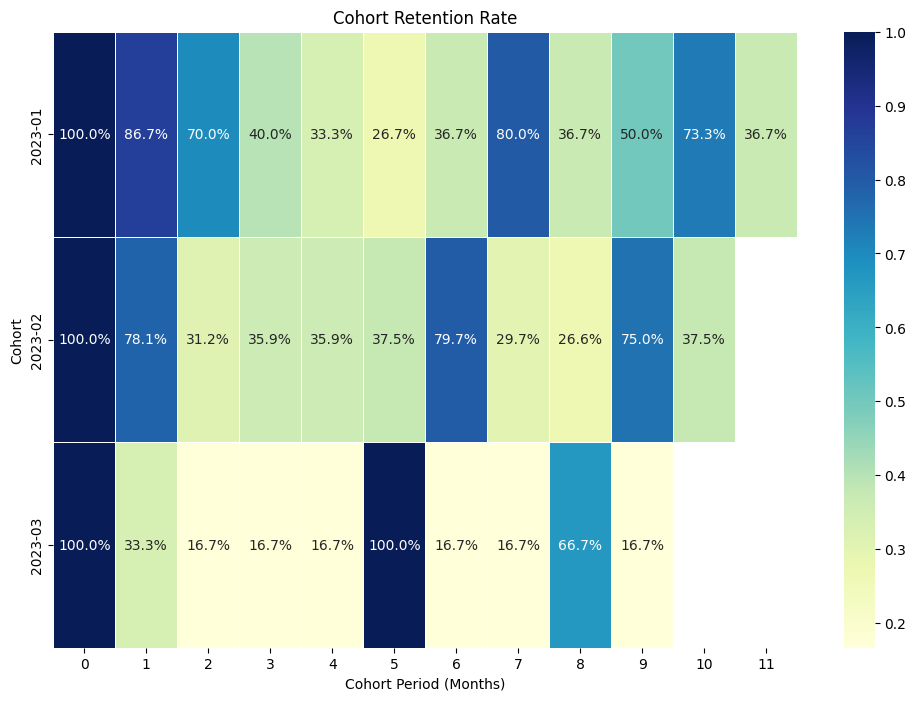

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu', linewidths=.5)
plt.title('Cohort Retention Rate')
plt.xlabel('Cohort Period (Months)')
plt.ylabel('Cohort')
plt.show()

## Understanding Cohort Analysis

Cohort analysis is a powerful analytical technique that allows you to examine the behavior of specific user groups (cohorts) over time. Instead of looking at all users as a single unit, which can mask important trends, cohort analysis segments users based on a shared characteristic or experience during a specific time frame.

### What is a Cohort?

A cohort is a group of users who share a common characteristic or experience within a defined time span. In our case, we defined cohorts based on the **month of their first purchase** (`First_Order_Date`). For example, all customers who made their first purchase in January 2023 belong to the '2023-01' cohort.

### Why is Cohort Analysis Useful?

1.  **Understand Customer Behavior Trends:** It reveals how different groups of customers behave over their lifecycle, rather than just aggregate metrics.
2.  **Identify Retention Issues:** You can see if newer cohorts are less loyal or have shorter lifespans than older ones, indicating potential product or marketing issues.
3.  **Measure Impact of Changes:** If you make changes to your product, pricing, or marketing, cohort analysis helps you see the long-term impact on specific groups of users.
4.  **Personalize Strategies:** By understanding distinct cohort behaviors, you can tailor strategies to improve retention, engagement, and revenue for each group.
5.  **Predict Future Performance:** Consistent cohort behavior can help in forecasting future customer value and business growth.

### Key Steps in Performing Cohort Analysis (as we did):

1.  **Define a Cohort:**
    *   **Characteristic:** Choose a defining event. Common choices include the user's sign-up date, first purchase date, or app install date.
    *   **Time Period:** Group these events into specific time intervals (e.g., daily, weekly, monthly).
    *   **Our Example:** We defined cohorts by the `First_Order_Date` of each customer, grouped by month (`df['Cohort'] = df['First_Order_Date'].dt.to_period('M')`).

2.  **Calculate Cohort Period (or Age):**
    *   Determine how much time has passed since each cohort's defining event for every subsequent action.
    *   **Our Example:** We calculated `Cohort_Period` by finding the difference in months between each `Order_Date` and the `First_Order_Date` for that customer (`df['Cohort_Period'] = (df['Order_Date'].dt.to_period('M') - df['Cohort']).apply(lambda x: x.n)`). A `Cohort_Period` of 0 means the month of their first purchase, 1 means the next month, and so on.

3.  **Aggregate Data:**
    *   Count the number of active users (or total revenue, etc.) for each `Cohort` and `Cohort_Period`.
    *   **Our Example:** We grouped by `Cohort` and `Cohort_Period` and counted unique `Customer_ID`s to get `cohort_counts`, which we then pivoted into `cohort_matrix`.

4.  **Normalize Data (Calculate Retention Rate):**
    *   To compare cohorts effectively, normalize the data. For retention analysis, this means dividing the number of active users in each subsequent period by the initial size of the cohort.
    *   **Our Example:** We calculated `cohort_sizes` (the number of unique customers in `Cohort_Period` 0 for each cohort) and then divided `cohort_matrix` by these sizes to get `retention_matrix`.

5.  **Visualize Results:**
    *   Heatmaps are commonly used to visualize retention matrices, making trends and patterns easily discernible.
    *   **Our Example:** We used `seaborn.heatmap` to create a visual representation of the `retention_matrix`, with percentages for clarity.

### Interpreting the Heatmap

*   **Rows (Cohorts):** Each row represents a different acquisition cohort (e.g., customers who made their first purchase in January 2023).
*   **Columns (Cohort Period):** Each column represents the number of periods (months, in our case) since the cohort's first interaction. `Cohort Period 0` is always 100% retention, as it's the initial month.
*   **Color Intensity:** Typically, darker colors (or higher percentages) indicate better retention. As you move across a row, you'll generally see a decrease in retention, which is expected as customers churn over time.
*   **Horizontal Trends:** Compare numbers *across* a single row to see how a specific cohort's behavior changes over time. Does retention drop sharply or gradually?
*   **Vertical Trends:** Compare numbers *down* a single column (e.g., all `Cohort Period 1` values) to see if newer cohorts are retaining better or worse than older cohorts at the same lifecycle stage.
*   **Diagonal Trends:** Sometimes you can spot trends related to seasonality or specific events that affect all cohorts at a certain calendar time, regardless of their `Cohort_Period`.

By carefully examining the heatmap, you can identify if there are specific cohorts performing better or worse, or if there's a particular period where customers tend to drop off significantly.